In [1376]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.special import jn_zeros

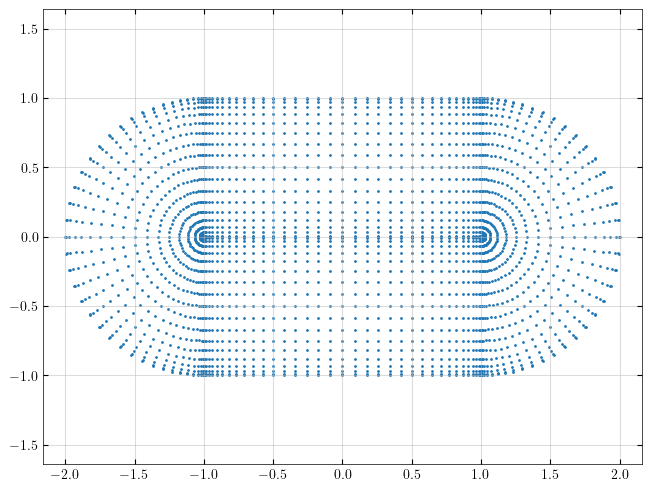

In [1377]:
geometry = "stadium"
x = np.loadtxt(f"../results/{geometry}_x.csv")
y = np.loadtxt(f"../results/{geometry}_y.csv")
plt.scatter(x, y, s=1)
plt.axis('equal')
plt.show()

(2964, 2039)


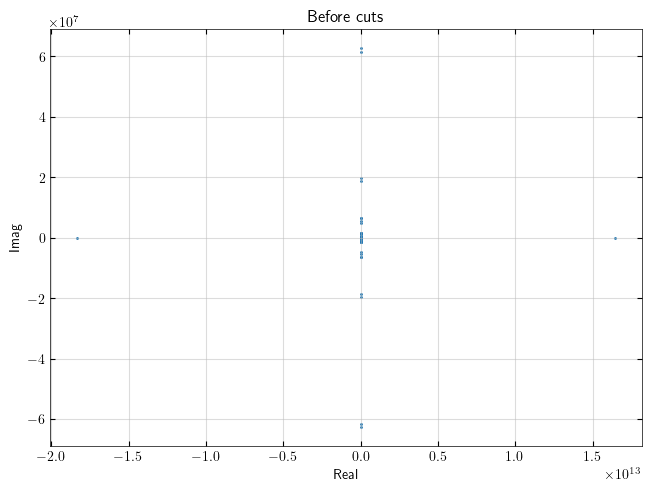

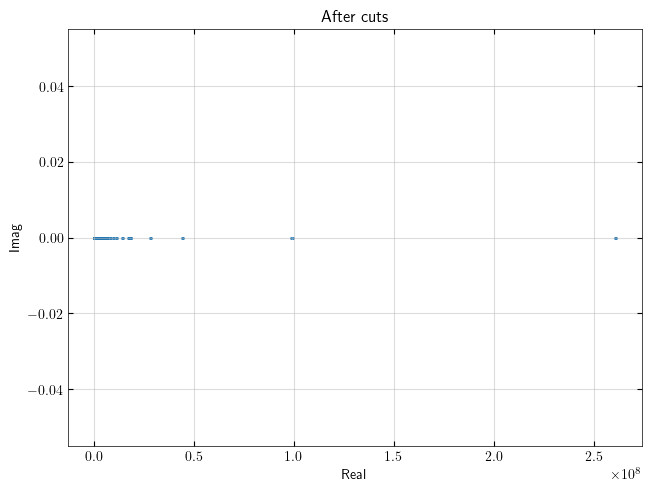

In [1393]:
eigval_real = np.loadtxt(f"../results/{geometry}_eigval_real.csv")
eigval_imag = np.loadtxt(f"../results/{geometry}_eigval_imag.csv")
eigvec_real = np.loadtxt(f"../results/{geometry}_eigvec_real.csv", delimiter=",")
eigvec_imag = np.loadtxt(f"../results/{geometry}_eigvec_imag.csv", delimiter=",")

if np.all(eigval_imag == 0):
    eigval = np.real(eigval)
    print("All eigenvalues real!")

print(eigvec.shape)

cut = (
    (np.abs(eigval_real) < 1e12)
    & (np.abs(eigval_imag) < 0.01)
      )

plt.figure()
plt.scatter(eigval_real, eigval_imag, s=1)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.title("Before cuts")
plt.show()

eigval_real = eigval_real[cut]
eigval_imag = eigval_imag[cut]
eigvec_real = eigvec_real[:, cut]
eigvec_imag = eigvec_imag[:, cut]

plt.figure()
plt.scatter(eigval_real, eigval_imag, s=1)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.title("After cuts")
plt.show()

In [1394]:
A = np.loadtxt("../A.csv", delimiter = ",")
B = np.loadtxt("../B.csv", delimiter = ",")
print(f"Matrix A sparsity: {100*np.sum(A==0)/np.size(A):.4f}%")
print(f"Matrix B sparsity: {100*np.sum(B==0)/np.size(B):.4f}%")
print(A.shape)
if A.shape[0] < 100:
    for row in A:
        print("".join("#" if x != 0 else "." for x in row))
        #print("".join(f"{x:.2f} " for x in row))

Matrix A sparsity: 98.2289%
Matrix B sparsity: 99.9713%
(2964, 2964)


In [1395]:
eigval = eigval_real + 1j*eigval_imag
eigvec = eigvec_real + 1j*eigvec_imag
amplitude = np.abs(eigvec)**2
eigval_abs = np.abs(eigval)
idx = np.argsort(eigval_abs)
eigval_abs_sort = eigval_abs[idx]
eigvec_sort = eigvec[:, idx]
amplitude_sort = amplitude[:, idx]

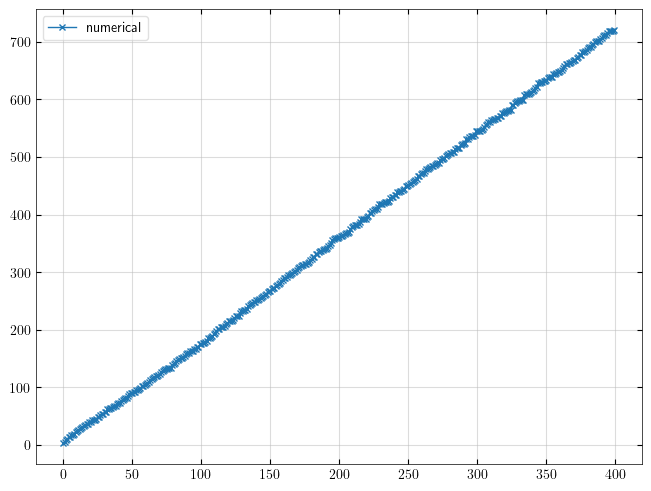

In [1396]:
if geometry == "square":
    L_x = max(x) - min(x)
    L_y = max(y) - min(y)
    exact = np.pi**2 * np.sort(np.array([(i/L_x)**2 + (j/L_y)**2 
                  for i in range(1, 100) for j in range(1, 100)]))
elif geometry == "semicircle":
    exact = np.sort(np.ravel([jn_zeros(n, 100)**2 for n in range(1, 100)]))
elif geometry == "circle":
    exact = np.sort(np.ravel(np.concatenate([
        [jn_zeros(0, 100)**2],
        [jn_zeros(n, 100)**2 for n in range(1, 100) for polarization in ["x", "y"]]])))

if geometry in ["square", "semicircle", "circle"]:
    exact = exact[:len(eigval_abs_sort)]
    rel_error = (eigval_abs_sort - exact) / exact
    print("   Exact,       Numerical")
    for i in range(20):
        print(f"{i}: {exact[i]:.6f}, {eigval_abs_sort[i]:.6f}")
    
xlim = 400 #len(eigval_abs)//3
log = False
    
plt.figure()
plt.plot(eigval_abs_sort[:xlim], marker='x', markersize=5, linewidth=1, label = "numerical")
if geometry in ["square", "semicircle", "circle"]:
    plt.plot(exact[:xlim], marker = 'o', markersize = 2, linewidth=1, linestyle = ":", label = "exact")
plt.legend()

if geometry in ["square", "semicircle", "circle"]:
    plt.figure()
    plt.plot(eigval_abs_sort[:xlim] - exact[:xlim], marker='x', markersize=3, linewidth=1, label = 'Error')
    if log:
        plt.yscale('log')
    plt.legend()
    
    plt.figure()
    plt.plot(np.abs(rel_error[:xlim]), marker='x', markersize=3, linewidth=1, label = 'Relative error')
    if log:
        plt.yscale('log')
    plt.legend()
    
plt.show()

In [1421]:
def interpolate_2d(x, y, z):
    N = int(np.ceil(4*np.sqrt(len(x))))
    xi = np.linspace(min(x), max(x), N)
    yi = np.linspace(min(y), max(y), N)
    X_grid, Y_grid = np.meshgrid(xi, yi)
    
    Z = griddata(
        (x, y),
        z,
        (X_grid, Y_grid),
        method='cubic'
    )
    return (X_grid, Y_grid, Z)

def interpolated_residual(x, y, z, eps):
    """
    Evaluates the residual of numerical solution to particle in a box -del^2 psi = eps*psi
    x, y: flattened vector of x, y coordinates of all points
    z: flattened complex vector of the wavefunction at each point
    """
    X_grid, Y_grid, Z_real = interpolate_2d(x, y, np.real(z))
    X_grid, Y_grid, Z_imag = interpolate_2d(x, y, np.imag(z))
    Z = Z_real + 1j*Z_imag
    dx = np.diff(X_grid[0, :])[0]
    dy = np.diff(Y_grid[:, 0])[0]
    uxx_real = np.gradient(np.gradient(Z_real, dx, axis = 1), dx, axis = 1)
    uxx_imag = np.gradient(np.gradient(Z_imag, dx, axis = 1), dx, axis = 1)
    uyy_real = np.gradient(np.gradient(Z_real, dy, axis = 0), dy, axis = 0)
    uyy_imag = np.gradient(np.gradient(Z_imag, dy, axis = 0), dy, axis = 0)
    uxx = uxx_real + 1j*uxx_imag
    uyy = uyy_real + 1j*uyy_imag
    res = np.abs(uxx + uyy) - np.abs(eps*Z)
    return X_grid, Y_grid, res
    
def plot_interpolated(x, y, z):
    X_grid, Y_grid, Z = interpolate_2d(x, y, z)
    Z = np.clip(Z, 0, None)
    plt.contourf(X_grid, Y_grid, Z, levels=50)
    plt.colorbar(label='Amplitude')
    plt.scatter(x[z==0], y[z==0], c='r', alpha = 1, s=2)
    plt.scatter(x[z!=0], y[z!=0], c='k', alpha = 0.5, s=2)
    plt.axis('equal')

def plot_error(x, y, z, eps, clip = None):
    X_grid, Y_grid, res = interpolated_residual(x, y, z, eps)
    res_clip = np.clip(res, -clip, clip)
    vmax = np.nanmax(np.abs(res_clip))
    plt.contourf(X_grid, Y_grid, res_clip, levels=50, cmap = 'bwr', vmin = -vmax, vmax = vmax)
    plt.colorbar(label='Error')
    plt.scatter(x, y, c='k', alpha = 0.1, s=1)
    plt.axis('equal')


BCs satisfied: True


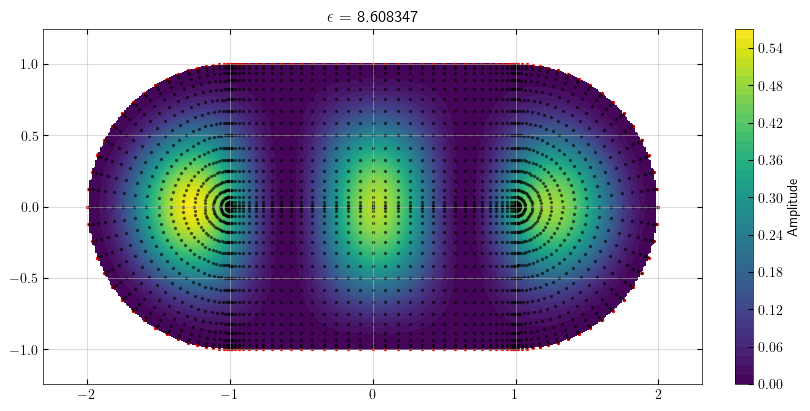

In [1427]:
i = 2
psi = eigvec_sort[:, i]
psi2 = amplitude_sort[:,i]
eps = eigval_abs_sort[i]

if geometry == "stadium":
    plt.figure(figsize = (2*(max(x) - min(x)), 2*(max(y)-min(y))))
    select = ((x <= -1) & (np.abs((x+1)**2 + y**2 - 1) < 1e-9)) ^ (y == 1) ^ (y == -1)^ ((x >= 1) & (np.abs((x-1)**2 + y**2 - 1) < 1e-9))
    print(f"BCs satisfied: {np.all(psi2[select]==0)}")
plot_interpolated(x, y, psi2)
plt.title(rf"$\epsilon$ = {eps:.6f}")
plt.show()

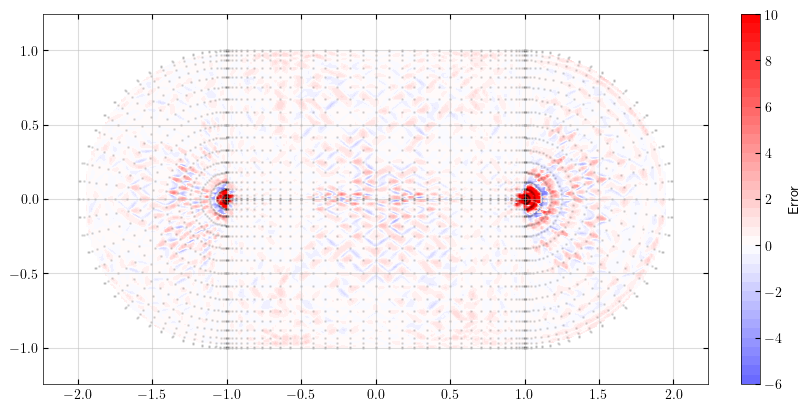

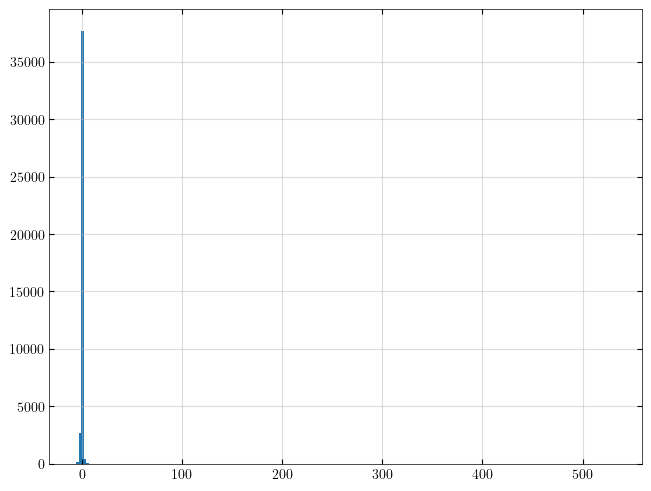

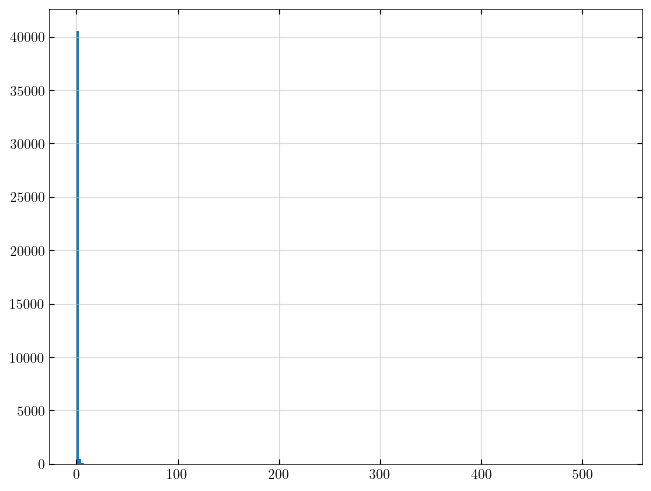

In [1431]:
clip = 10

if geometry == "stadium":
    plt.figure(figsize = (2*(max(x) - min(x)), 2*(max(y)-min(y))))
plot_error(x, y, psi, eps, clip = clip)
plt.show()

_, _, res = interpolated_residual(x, y, psi, eps)
plt.hist(res.ravel(), bins = int(np.sqrt(res.size)))
plt.show()

plt.hist(np.abs(res.ravel()), bins = int(np.sqrt(res.size)))
plt.show()


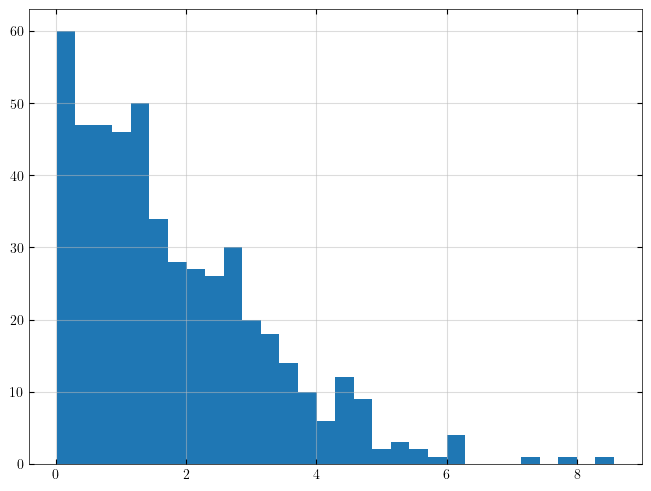

In [1429]:
plt.hist(np.diff(eigval_abs_sort[:500]), bins = 30)
plt.show()